In [1]:
# Quick knobs (change these most often)
BATCH_SIZE = 1024                # Batch size for tokenization
MAX_DOCS = None                  # e.g. 10000 for a quick dry run
TRACK_TOKEN_FREQUENCY = False    # True = compute most common tokens (slower)
TOP_N_TOKENS = 20                # Number of top tokens to display
ADD_SPECIAL_TOKENS = False       # Include special tokens in counts or not

TOKENIZER_CANDIDATES = [
    "Qwen/Qwen3-0.B",
    "Qwen/Qwen2.5-0.5B-Instruct",
]

# Token count EDA for chunked knowledge base
from pathlib import Path
import json
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from transformers import AutoTokenizer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CHUNKS_PATH = PROJECT_ROOT / "data" / "processed" / "knowledge" / "chunks.jsonl"

SOURCE_LABELS = {
    "pubmedqa": "Word-based (PubMedQA)",
    "medqa": "Character-based (MedQA)",
}

def load_chunks_jsonl(path: Path, max_docs: int | None = None) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_docs is not None and i >= max_docs:
                break
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

df_chunks = load_chunks_jsonl(CHUNKS_PATH, max_docs=MAX_DOCS)
print(f"Loaded {len(df_chunks):,} chunks from {CHUNKS_PATH}")
display(df_chunks.head(3))
display(df_chunks["source"].value_counts())

Loaded 276,024 chunks from /Volumes/HP_P900/Users/tungnguyen/Programming/bio-med-rag/data/processed/knowledge/chunks.jsonl


,doc_id,chunk_id,text,source
0,25429730,25429730_0,Chronic rhinosinusitis (CRS) is a heterogeneou...,pubmedqa
1,25433161,25433161_0,Phosphatidylethanolamine N-methyltransferase (...,pubmedqa
2,25445714,25445714_0,Psammaplin A (PsA) is a natural product isolat...,pubmedqa


source
pubmedqa    273886
medqa         2138
Name: count, dtype: int64

In [2]:
def load_tokenizer(candidates: list[str]) -> tuple[AutoTokenizer, str]:
    last_err = None
    for name in candidates:
        try:
            tok = AutoTokenizer.from_pretrained(name, trust_remote_code=True)
            return tok, name
        except Exception as e:
            last_err = e
            print(f"Tokenizer load failed for {name}: {e}")
    raise RuntimeError(f"Could not load any tokenizer from {candidates}. Last error: {last_err}")

def tokenize_in_batches(
    texts: list[str],
    sources: list[str],
    tokenizer: AutoTokenizer,
    batch_size: int = 1024,
    track_token_frequency: bool = False,
    add_special_tokens: bool = False,
):
    token_counts = []
    token_freq_by_source = defaultdict(Counter)
    token_freq_all = Counter()

    for start in tqdm(range(0, len(texts), batch_size), desc="Tokenizing batches"):
        end = min(start + batch_size, len(texts))
        batch_texts = texts[start:end]
        batch_sources = sources[start:end]

        enc = tokenizer(
            batch_texts,
            add_special_tokens=add_special_tokens,
            truncation=False,
            padding=False,
        )

        input_ids = enc["input_ids"]
        token_counts.extend(len(ids) for ids in input_ids)

        if track_token_frequency:
            for src, ids in zip(batch_sources, input_ids):
                token_freq_by_source[src].update(ids)
                token_freq_all.update(ids)

    return np.array(token_counts), token_freq_by_source, token_freq_all

tokenizer, tokenizer_name = load_tokenizer(TOKENIZER_CANDIDATES)
print(f"Using tokenizer: {tokenizer_name}")

token_counts, token_freq_by_source, token_freq_all = tokenize_in_batches(
    texts=df_chunks["text"].tolist(),
    sources=df_chunks["source"].tolist(),
    tokenizer=tokenizer,
    batch_size=BATCH_SIZE,
    track_token_frequency=TRACK_TOKEN_FREQUENCY,
    add_special_tokens=ADD_SPECIAL_TOKENS,
)

df_tokens = df_chunks[["doc_id", "chunk_id", "source"]].copy()
df_tokens["chunk_type"] = df_tokens["source"].map(SOURCE_LABELS).fillna(df_tokens["source"])
df_tokens["token_count"] = token_counts

display(df_tokens.head(3))
display(df_tokens.groupby("chunk_type")["token_count"].describe().round(2))

Tokenizer load failed for Qwen/Qwen3-0.B: Qwen/Qwen3-0.B is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
Using tokenizer: Qwen/Qwen2.5-0.5B-Instruct


Tokenizing batches:   0%|          | 0/270 [00:00<?, ?it/s]

,doc_id,chunk_id,source,chunk_type,token_count
0,25429730,25429730_0,pubmedqa,Word-based (PubMedQA),467
1,25433161,25433161_0,pubmedqa,Word-based (PubMedQA),388
2,25445714,25445714_0,pubmedqa,Word-based (PubMedQA),118


,count,mean,std,min,25%,50%,75%,max
chunk_type,,,,,,,,
Character-based (MedQA),2138.0,428.43,141.24,2.0,370.0,398.0,449.0,1814.0
Word-based (PubMedQA),273886.0,325.71,99.51,11.0,261.0,319.0,380.0,1284.0


,group,n_chunks,mean,variance,std,min,q25,median,q75,max,most_common_token_count_mode
0,Character-based (MedQA),2138,428.430,19948.053,141.238,2,370.0,398.0,449.0,1814,392
1,Word-based (PubMedQA),273886,325.707,9902.911,99.513,11,261.0,319.0,380.0,1284,325
2,Merged (All chunks),276024,326.503,10061.746,100.308,2,261.0,320.0,381.0,1814,326


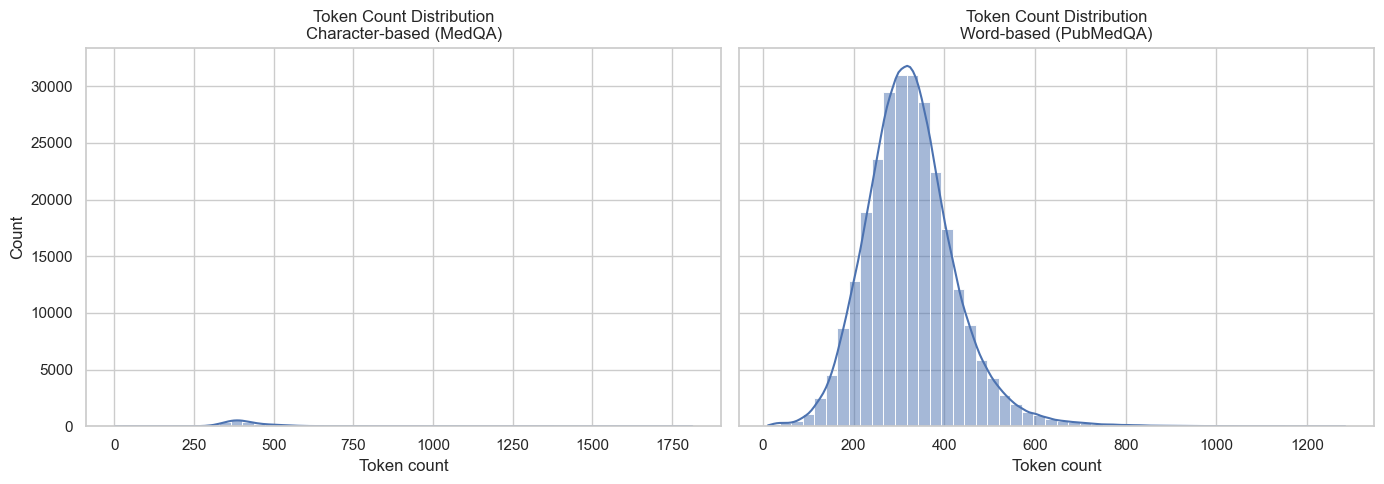

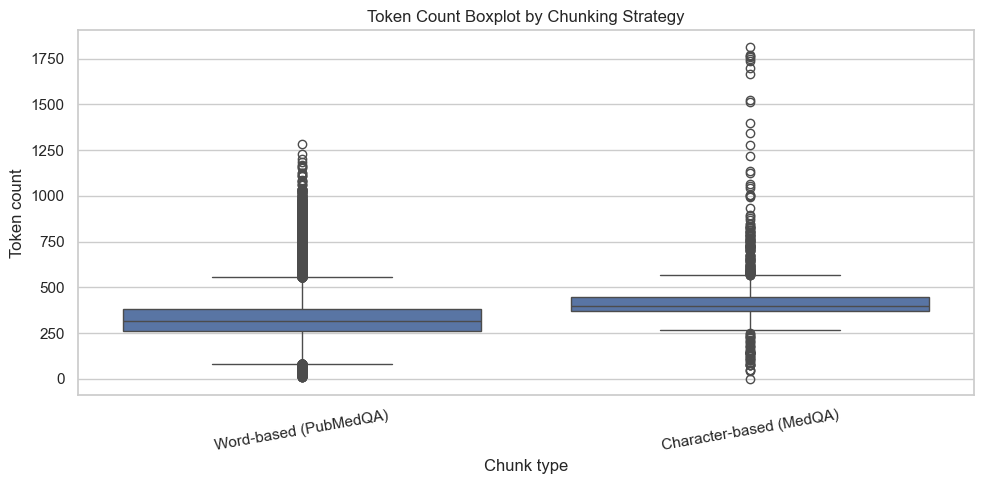

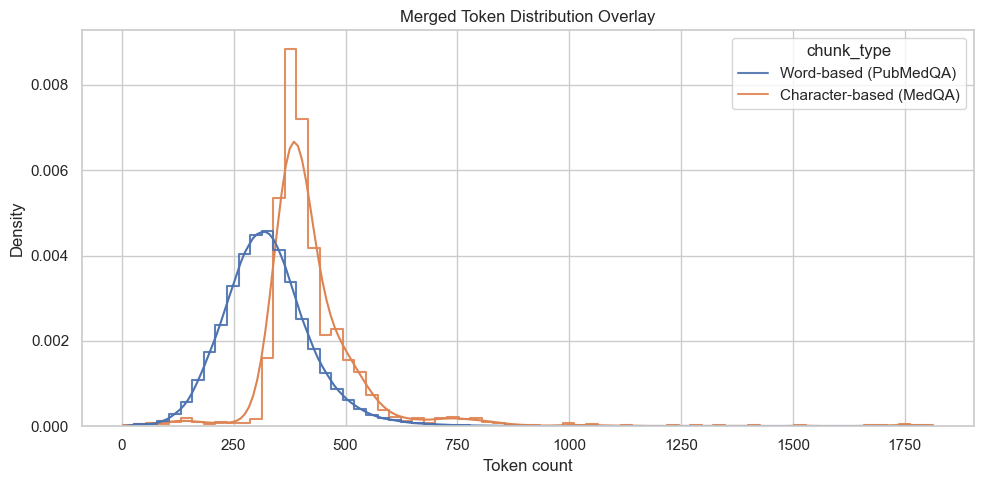

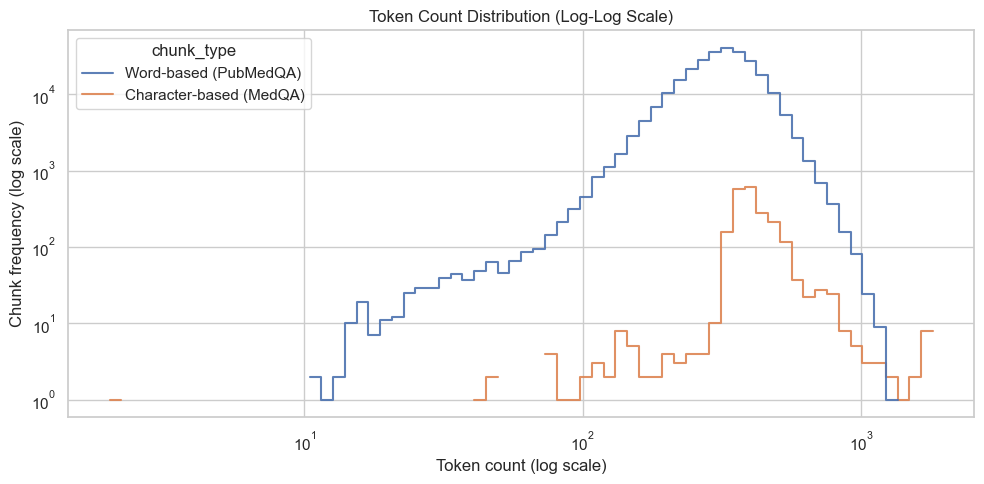

In [3]:
def summarize_distribution(series: pd.Series, name: str) -> dict:
    mode_values = series.mode()
    mode_value = int(mode_values.iloc[0]) if len(mode_values) > 0 else None
    return {
        "group": name,
        "n_chunks": int(series.shape[0]),
        "mean": float(series.mean()),
        "variance": float(series.var(ddof=1)) if len(series) > 1 else 0.0,
        "std": float(series.std(ddof=1)) if len(series) > 1 else 0.0,
        "min": int(series.min()),
        "q25": float(series.quantile(0.25)),
        "median": float(series.median()),
        "q75": float(series.quantile(0.75)),
        "max": int(series.max()),
        "most_common_token_count_mode": mode_value,
    }

stats_rows = []
for chunk_type in sorted(df_tokens["chunk_type"].unique()):
    s = df_tokens.loc[df_tokens["chunk_type"] == chunk_type, "token_count"]
    stats_rows.append(summarize_distribution(s, chunk_type))

stats_rows.append(summarize_distribution(df_tokens["token_count"], "Merged (All chunks)"))
stats_df = pd.DataFrame(stats_rows)
display(stats_df.round(3))

# Histogram by separate chunking strategy
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, chunk_type in zip(axes, sorted(df_tokens["chunk_type"].unique())):
    sns.histplot(
        data=df_tokens[df_tokens["chunk_type"] == chunk_type],
        x="token_count",
        bins=50,
        kde=True,
        ax=ax,
    )
    ax.set_title(f"Token Count Distribution\n{chunk_type}")
    ax.set_xlabel("Token count")
plt.tight_layout()
plt.show()

# Boxplot comparison (separate + merged view context)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_tokens, x="chunk_type", y="token_count")
plt.title("Token Count Boxplot by Chunking Strategy")
plt.xlabel("Chunk type")
plt.ylabel("Token count")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Merged overlay distribution
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_tokens,
    x="token_count",
    hue="chunk_type",
    bins=70,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    kde=True,
    alpha=0.9,
 )
plt.title("Merged Token Distribution Overlay")
plt.xlabel("Token count")
plt.tight_layout()
plt.show()

# Log-scale distribution (better long-tail visibility)
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_tokens,
    x="token_count",
    hue="chunk_type",
    bins=70,
    stat="count",
    common_norm=False,
    element="step",
    fill=False,
    log_scale=(True, True),
    alpha=0.9,
 )
plt.title("Token Count Distribution (Log-Log Scale)")
plt.xlabel("Token count (log scale)")
plt.ylabel("Chunk frequency (log scale)")
plt.tight_layout()
plt.show()

In [4]:
def top_tokens(counter: Counter, tokenizer: AutoTokenizer, n: int = 20) -> pd.DataFrame:
    rows = []
    for token_id, freq in counter.most_common(n):
        token_text = tokenizer.decode([token_id], skip_special_tokens=False)
        rows.append({"token_id": token_id, "token_text": token_text, "frequency": freq})
    return pd.DataFrame(rows)

if TRACK_TOKEN_FREQUENCY:
    print("Top tokens by chunk type")
    for src in sorted(token_freq_by_source.keys()):
        label = SOURCE_LABELS.get(src, src)
        print(f"\n===== {label} =====")
        display(top_tokens(token_freq_by_source[src], tokenizer, n=TOP_N_TOKENS))

    print("\n===== Merged (All chunks) =====")
    display(top_tokens(token_freq_all, tokenizer, n=TOP_N_TOKENS))
else:
    print("Most-common-token analysis is disabled.")
    print("Set TRACK_TOKEN_FREQUENCY = True in Cell 1, then rerun Cell 2 and Cell 4.")

# Practical generation-budget guidance from this EDA
summary = df_tokens.groupby("chunk_type")["token_count"].quantile([0.5, 0.9, 0.95, 0.99]).unstack()
summary.columns = ["p50", "p90", "p95", "p99"]
display(summary.round(1))

print("\nSuggested use:")
print("- Use p90 or p95 retrieved-context token count as your starting context budget.")
print("- Then reserve output tokens separately (e.g., 128-512) based on answer length needs.")
print("- Re-check after changing chunk sizes or retriever top-k.")

Most-common-token analysis is disabled.
Set TRACK_TOKEN_FREQUENCY = True in Cell 1, then rerun Cell 2 and Cell 4.


,p50,p90,p95,p99
chunk_type,,,,
Character-based (MedQA),398.0,529.0,612.7,996.4
Word-based (PubMedQA),319.0,447.0,495.0,620.0



Suggested use:
- Use p90 or p95 retrieved-context token count as your starting context budget.
- Then reserve output tokens separately (e.g., 128-512) based on answer length needs.
- Re-check after changing chunk sizes or retriever top-k.
